# 04 — XGBoost + SHAP: Giai thich gia dien phi tuyen

**Muc tieu:** Danh gia hieu suat Walk-Forward va giai thich cac nhan to quyet dinh gia
bang phuong phap SHAP.

**Yeu cau:** `data/processed/electricity_dataset_with_regimes.csv` va thu muc `artifacts/`
(chay `trainer.py` truoc de huan luyen va luu mo hinh).

---

## Ly thuyet nen tang

### 1. XGBoost — Gradient Boosting cay quyet dinh

XGBoost (Chen & Guestrin, 2016) xay dung mot tap hop cay quyet dinh (ensemble) theo phuong phap
gradient boosting: moi cay moi duoc huan luyen de sua phan du cua cac cay truoc do.

Ham muc tieu co dang:
$$\mathcal{L} = \sum_i l(y_i, \hat{y}_i) + \sum_k \Omega(f_k)$$
trong do $\Omega(f_k) = \gamma T + \frac{1}{2}\lambda||w||^2$ la ham chinh quy hoa
kiem soat do phuc tap cay ($T$ = so la, $w$ = trong so la).

**Uu diem voi gia dien:** XGBoost bat duoc tuong tac phi tuyen (VD: TTF cao va Residual_Load
cao dong thoi → gia tang phi tuyen) va khong gia dinh phan phoi chuan.

**Han che:** Cay quyet dinh KHONG ngoai suy (extrapolate) ngoai khoang gia tri huan luyen.
Day la nguyen nhan R2 < 0 tai W3 (Test 2022): gia khi trong tap test vuot xa pham vi huan luyen.

### 2. Walk-Forward Expanding Window Validation

De ton trong thu tu thoi gian va tranh data leakage, chung ta khong the dung cross-validation
ngau nhien. Thay vao do, dung **expanding window**: moi window them 1 nam vao tap huan luyen:

```
W1: train [2018-2019] → test 2020
W2: train [2018-2020] → test 2021
W3: train [2018-2021] → test 2022  ← Khung hoang nang luong
W4: train [2018-2022] → test 2023
W5: train [2018-2023] → test 2024
W6: train [2018-2024] → test 2025
```

Early stopping su dung 20% cuoi tap huan luyen lam validation set (cat theo thu tu thoi gian).

**Hai cau hinh feature:**
- **C1 (3 features):** `Residual_Load`, `TTF_Gas_Price`, `EU_Gas_Storage_Anomaly`.
  Kiem tra lieu 3 bien nhan qua ly thuyet Merit Order co du de giai thich gia hay khong.
- **C2 (19 features):** C1 + cau truc vat ly chi tiet + `Physical_Cluster`.
  Do luong gia tri gia tang cua thong tin the che va he thong phat dien.

### 3. SHAP — Unified Model-Agnostic Explanation

SHAP (Lundberg & Lee, 2017) ap dung ly thuyet Shapley tu kinh te game hoc vao giai thich mo hinh ML:

$$\phi_i = \sum_{S \subseteq F \setminus \{i\}} \frac{|S|!(|F|-|S|-1)!}{|F|!} [f(S \cup \{i\}) - f(S)]$$

trong do $\phi_i$ la dong gop cua feature $i$ vao du bao, $S$ la tap con cac feature khac.
SHAP dam bao 3 tinh chat quan trong:
- **Hieu qua (Efficiency):** Tong SHAP values = du bao - gia tri trung binh.
- **Doi xung (Symmetry):** Hai feature dong gop nhu nhau → SHAP bang nhau.
- **Dummy:** Feature khong anh huong → SHAP = 0.

**TreeSHAP** (cai tien cho cay quyet dinh) tinh phi_i chinh xac trong O(TLD^2)
thay vi xap xi exponential.

**Y nghia ket qua:**
- `TTF_Gas_Price` SHAP cao → gia khi la nhan to quyet dinh gia (thi truong phu thuoc khi dot).
- `Physical_Cluster` xuat hien trong top-5 → nhan the che cung cap thong tin du bao them.


In [1]:
import os, sys, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Times', 'DejaVu Serif']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.unicode_minus'] = False
import matplotlib.patches as mpatches
import seaborn as sns
import shap
warnings.filterwarnings('ignore')
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, '.')
from src.models.forecaster import (
    run_walk_forward, compute_shap, C1_FEATURES, C2_FEATURES, WINDOWS
)
sns.set_theme(style='whitegrid')
OUT_DIR = 'reports/figures/03_xgboost'
os.makedirs(OUT_DIR, exist_ok=True)

In [2]:
df = pd.read_csv('data/processed/electricity_dataset_with_regimes.csv')
df['Datetime'] = pd.to_datetime(df['Datetime'], utc=True)
COUNTRIES = ['DE', 'DK', 'ES', 'FR', 'IT', 'PL']
print(f'{len(df):,} rows loaded')

420,768 rows loaded


## 1. Walk-Forward R² — Single Country

In [3]:
country = 'DE'  # Change to explore
results = run_walk_forward(df, country, feature_set='both', artifacts_dir='artifacts')
results[['Window','r2_c1','r2_c2']]

  [DE] W1 C1  R²=0.667 | MAE=6.6
  [DE] W1 C2  R²=0.173 | MAE=10.9
  [DE] W2 C1  R²=-0.661 | MAE=49.9


  [DE] W2 C2  R²=-0.860 | MAE=54.4
  [DE] W3 (Crisis) C1  R²=-2.191 | MAE=123.6


  [DE] W3 (Crisis) C2  R²=-2.113 | MAE=121.3


  [DE] W4 C1  R²=0.480 | MAE=22.9


  [DE] W4 C2  R²=0.555 | MAE=20.6


  [DE] W5 C1  R²=0.566 | MAE=16.2


  [DE] W5 C2  R²=0.510 | MAE=17.1
  [DE] W6 C1  R²=0.536 | MAE=19.2


  [DE] W6 C2  R²=0.541 | MAE=19.3


,Window,r2_c1,r2_c2
0,W1,0.667175,0.172560
1,W2,-0.660648,-0.859815
2,W3 (Crisis),-2.191360,-2.112830
3,W4,0.480168,0.554509
4,W5,0.565889,0.510300
5,W6,0.536063,0.541001


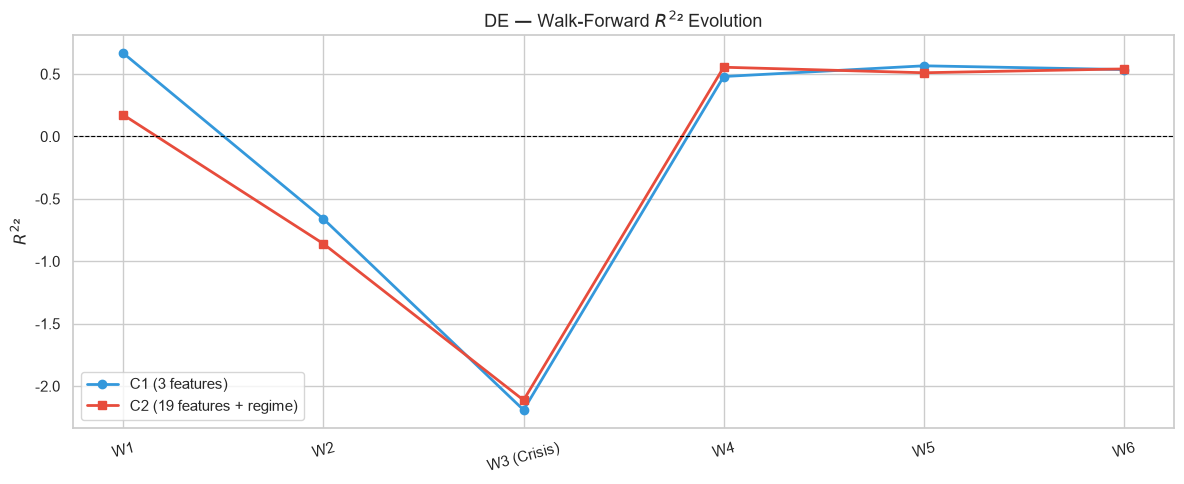

In [4]:
# Plot $R^2$² evolution
fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(results))
ax.plot(x, results['r2_c1'], 'o-', label='C1 (3 features)', color='#3498db', lw=2)
ax.plot(x, results['r2_c2'], 's-', label='C2 (19 features + regime)', color='#e74c3c', lw=2)
ax.axhline(0, color='black', ls='--', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels([w['label'] for w in WINDOWS], rotation=15)
ax.set_title(f'{country} — Walk-Forward $R^2$² Evolution', fontsize=13)
ax.set_ylabel('$R^2$²')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f'{country}_r2_evolution.png'), dpi=500, bbox_inches='tight')
plt.show()

## 2. All Countries — W6 Summary

In [5]:
# Load pre-computed results if available, else run all
results_path = 'reports/walk_forward_results.csv'
if os.path.exists(results_path):
    all_results = pd.read_csv(results_path)
    print('Loaded pre-computed results.')
else:
    print('Pre-computed results not found. unning walk-forward (takes ~10 min)...')
    from src.models.forecaster import run_all_countries
    all_results = run_all_countries(df, artifacts_dir='artifacts')
    all_results.to_csv(results_path, index=False)

w6 = all_results[all_results['Window'].str.contains('W6')]
w6[['Country','r2_c1','r2_c2']].assign(delta=lambda x: x.r2_c2-x.r2_c1).round(3)

Loaded pre-computed results.


,Country,r2_c1,r2_c2,delta
5,DE,0.528,0.565,0.037
11,DK,0.289,0.289,0.001
17,ES,0.356,0.374,0.019
23,FR,0.505,0.529,0.024
29,IT,-0.852,-0.938,-0.086
35,PL,0.282,0.285,0.003


## 3. SHAP Summary Plot — C1 (3 features)

Computing SHAP for DE C1...


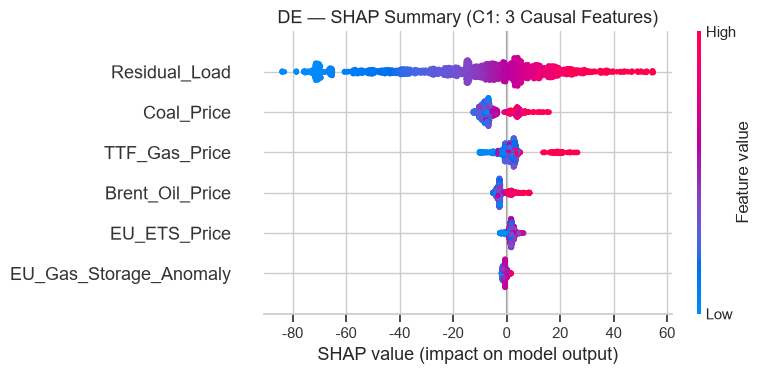

In [6]:
country = 'DE'
print(f'Computing SHAP for {country} C1...')
shap_vals, feats = compute_shap(df, country, feature_set='C1', n_sample=2000)
plt.figure(figsize=(10, 4))
shap.summary_plot(shap_vals, feature_names=feats, show=False)
plt.title(f'{country} — SHAP Summary (C1: 3 Causal Features)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f'{country}_C1_shap.png'), dpi=500, bbox_inches='tight')
plt.show()

## 4. SHAP Summary Plot — C2 (19 features)

Computing SHAP for DE C2...


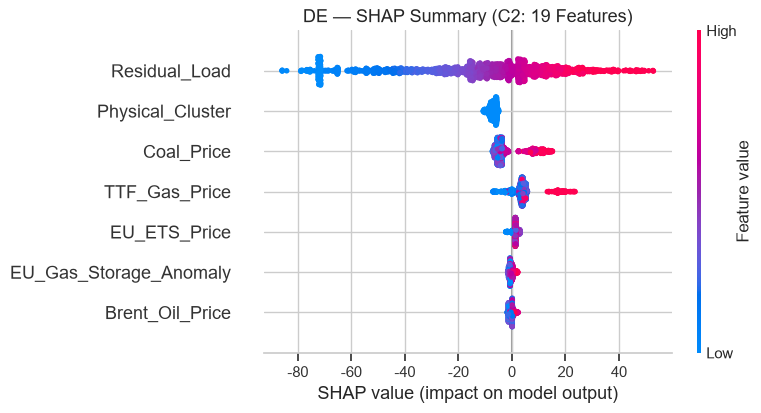

In [7]:
country = 'DE'
print(f'Computing SHAP for {country} C2...')
shap_vals_c2, feats_c2 = compute_shap(df, country, feature_set='C2', n_sample=2000)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals_c2, feature_names=feats_c2, max_display=15, show=False)
plt.title(f'{country} — SHAP Summary (C2: 19 Features)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f'{country}_C2_shap.png'), dpi=500, bbox_inches='tight')
plt.show()

## 5. Crisis Boundary — Residual Load × TTF Space

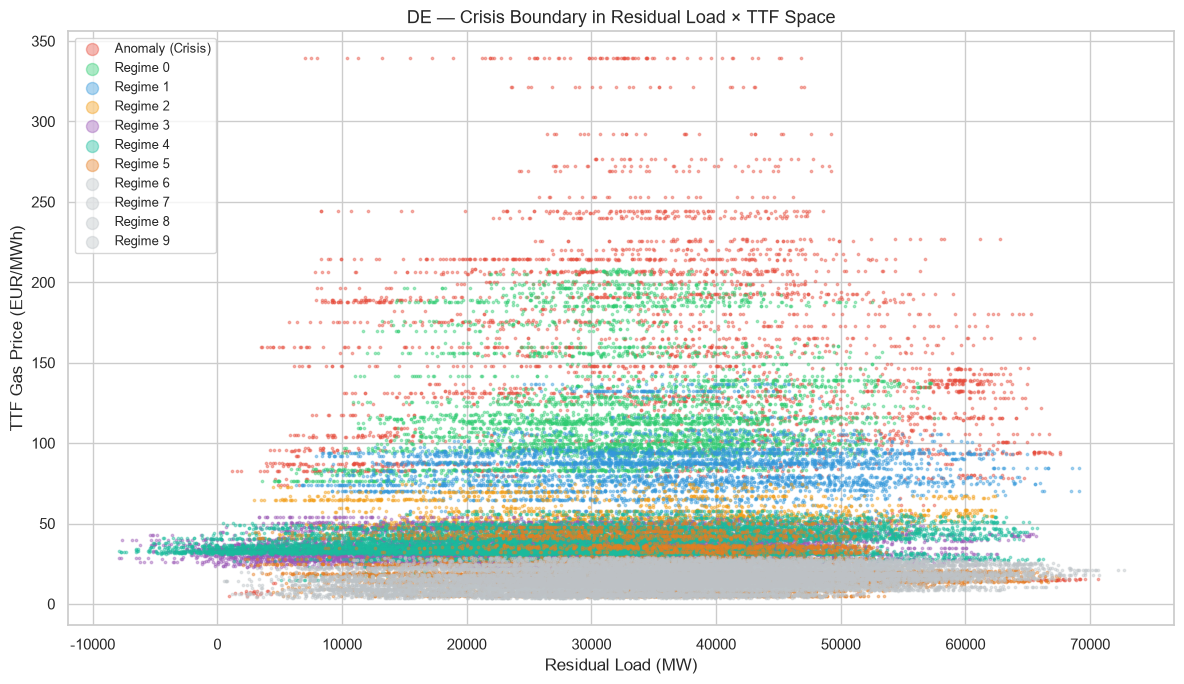

In [8]:
country = 'DE'
df_c = df[(df['Country'] == country)].copy()

PALETTE = {-2:'#e74c3c',-1:'#95a5a6', 0:'#2ecc71', 1:'#3498db',
           2:'#f39c12', 3:'#9b59b6', 4:'#1abc9c', 5:'#e67e22'}

fig, ax = plt.subplots(figsize=(12, 7))
for cluster in sorted(df_c['Physical_Cluster'].unique()):
    grp = df_c[df_c['Physical_Cluster'] == cluster]
    label = {-2:'Anomaly (Crisis)',-1:'Noise'}.get(cluster, f'Regime {cluster}')
    ax.scatter(grp['Residual_Load'], grp['TTF_Gas_Price'],
               color=PALETTE.get(cluster,'#bdc3c7'), s=3, alpha=0.4, label=label)

ax.set_xlabel('Residual Load (MW)', fontsize=12)
ax.set_ylabel('TTF Gas Price (EUR/MWh)', fontsize=12)
ax.set_title(f'{country} — Crisis Boundary in Residual Load × TTF Space', fontsize=13)
ax.legend(markerscale=5, fontsize=9, loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f'{country}_crisis_boundary.png'), dpi=500, bbox_inches='tight')
plt.show()

In [9]:
import shutil
import os
OUT_APP = "paper/figures/appendix"
os.makedirs(OUT_APP, exist_ok=True)
OUT_RES = "paper/figures/results"
os.makedirs(OUT_RES, exist_ok=True)

# 1. Copy DE R2 and Crisis to results
if os.path.exists(os.path.join(OUT_DIR, "DE_r2_evolution.png")):
    shutil.copy(os.path.join(OUT_DIR, "DE_r2_evolution.png"), os.path.join(OUT_RES, "DE_r2_evolution.png"))
if os.path.exists(os.path.join(OUT_DIR, "DE_crisis_boundary.png")):
    shutil.copy(os.path.join(OUT_DIR, "DE_crisis_boundary.png"), os.path.join(OUT_RES, "DE_crisis_boundary.png"))

# 2. Plot R2 Evolution for all countries
wf_res = all_results
fig, axes = plt.subplots(3, 2, figsize=(15, 10), sharex=True, sharey=True)
axes = axes.flatten()
for i, c in enumerate(COUNTRIES):
    c_res = wf_res[wf_res['Country'] == c].sort_values('Window')
    ax = axes[i]
    x = range(len(c_res))
    ax.plot(x, c_res['r2_c1'], 'o-', label='C1', color='#3498db', lw=2)
    ax.plot(x, c_res['r2_c2'], 's-', label='C2', color='#e74c3c', lw=2)
    ax.axhline(0, color='black', ls='--', lw=0.8)
    ax.set_title(f'{c} - R2 Evolution', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(c_res['Window'], rotation=15)
    if i == 0: ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_APP, "all_countries_r2_evolution.png"), dpi=500, bbox_inches='tight')
plt.close()

# 3. Plot Crisis Boundary for all countries
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()
for i, c in enumerate(COUNTRIES):
    df_c = df[df['Country'] == c]
    ax = axes[i]
    for cluster in sorted(df_c['Physical_Cluster'].unique()):
        grp = df_c[df_c['Physical_Cluster'] == cluster]
        label = {-2:'Anomaly (Crisis)',-1:'Noise'}.get(cluster, f'Regime {cluster}')
        ax.scatter(grp['Residual_Load'], grp['TTF_Gas_Price'], color=PALETTE.get(cluster,'#bdc3c7'), s=3, alpha=0.4, label=label)
    ax.set_title(f'{c} - Crisis Boundary', fontsize=12)
    ax.set_xlabel('Residual Load (MW)')
    ax.set_ylabel('TTF Gas Price')
    if i == 0: ax.legend(markerscale=3, fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT_APP, "all_countries_crisis_boundary.png"), dpi=500, bbox_inches='tight')
plt.close()
print("Plots integrated into Notebook 04!")

Plots integrated into Notebook 04!
